# Importation Google Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# Importation des données pour la régression

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import poisson,skellam
from scipy.optimize import minimize
import pickle
from scipy.stats import poisson
from string import ascii_uppercase as alphabet
from random import choices
import statsmodels.api as sm
import statsmodels.formula.api as smf

epl_1718 = pd.read_csv("https://www.football-data.co.uk/mmz4281/2324/E0.csv")
epl_1718 = epl_1718[['HomeTeam','AwayTeam','FTHG','FTAG']]
epl_1718 = epl_1718.rename(columns={'FTHG': 'HomeGoals', 'FTAG': 'AwayGoals'})
epl_1718['HomeTeam'].replace('Man United', 'Manchester Utd', inplace=True)
epl_1718['HomeTeam'].replace('Nott\'m Forest', 'Nottingham', inplace=True)
epl_1718['HomeTeam'].replace('Man City', 'Manchester City', inplace=True)
epl_1718['HomeTeam'].replace('Sheffield United', 'Sheffield Utd', inplace=True)
epl_1718['AwayTeam'].replace('Man United', 'Manchester Utd', inplace=True)
epl_1718['AwayTeam'].replace('Nott\'m Forest', 'Nottingham', inplace=True)
epl_1718['AwayTeam'].replace('Man City', 'Manchester City', inplace=True)
epl_1718['AwayTeam'].replace('Sheffield United', 'Sheffield Utd', inplace=True)
epl_1718

In [ ]:
fifarank = pd.read_csv('/content/drive/MyDrive/CSV/fifaranklast.csv')
for i in range(0,54):
  ind=0
  if fifarank['country_full'][i]=="Turkiye":
    fifarank['country_full'][i]="Turkey"

fifarank_Home = fifarank.rename(columns={'country_full': 'HomeCountry', 'total_points': 'Home_Team_Fifa_Points'})
fifarank_Away = fifarank.rename(columns={'country_full': 'AwayCountry', 'total_points': 'Away_Team_Fifa_Points'})

def points(team):
  ind=0
  for i in range(0,54):
    if fifarank['country_full'][i]==team:
      ind=i
      return(fifarank['total_points'][i])
    if (team == "Turkey"):
      if fifarank['country_full'][i]=="Turkiye":
        ind=i
        return(fifarank['total_points'][i])
points('Turkey')

fifarank_Home

In [ ]:
#Correction fifa_rk
for i in range(0,54):
  ind=0
  if fifarank['country_full'][i]=="France":
    fifarank['total_points'][i]=1840.32
  if fifarank['country_full'][i]=="Belgium":
    fifarank['total_points'][i]=1795.32
  if fifarank['country_full'][i]=="England":
    fifarank['total_points'][i]=1795.00
  if fifarank['country_full'][i]=="Portugal":
    fifarank['total_points'][i]=1748.32
  if fifarank['country_full'][i]=="Netherlands":
    fifarank['total_points'][i]=1742.32
  if fifarank['country_full'][i]=="Spain":
    fifarank['total_points'][i]=1727.32
  if fifarank['country_full'][i]=="Italy":
    fifarank['total_points'][i]=1724.32
  if fifarank['country_full'][i]=="Croatia":
    fifarank['total_points'][i]=1721.32

  if fifarank['country_full'][i]=="Switzerland":
    fifarank['total_points'][i]=1616.32
  if fifarank['country_full'][i]=="Denmark":
    fifarank['total_points'][i]=1602.32
  if fifarank['country_full'][i]=="Ukraine":
    fifarank['total_points'][i]=1568.32
  if fifarank['country_full'][i]=="Austria":
    fifarank['total_points'][i]=1554.32
  if fifarank['country_full'][i]=="Hungary":
    fifarank['total_points'][i]=1532.32
  if fifarank['country_full'][i]=="Sweden":
    fifarank['total_points'][i]=1531.32
  if fifarank['country_full'][i]=="Poland":
    fifarank['total_points'][i]=1531.32
  if fifarank['country_full'][i]=="Finland":
    fifarank['total_points'][i]=1394.32


In [ ]:
import pandas as pd
données=pd.read_csv('/content/drive/MyDrive/CSV/international-uefa-euro-qualifiers-matches-2022-to-2024-stats (1).csv')
données=données[['date_GMT','home_team_name','away_team_name','home_team_goal_count','away_team_goal_count','total_goal_count']]
données.head()
données_propres=données[['home_team_name','away_team_name','home_team_goal_count','away_team_goal_count']]
epl_1718 = données_propres.rename(columns={'home_team_goal_count': 'HomeGoals', 'away_team_goal_count': 'AwayGoals','home_team_name': 'HomeTeam','away_team_name': 'AwayTeam'})
epl_1718

,HomeTeam,AwayTeam,HomeGoals,AwayGoals
0,Kazakhstan,Slovenia,1,2
1,Italy,England,1,2
2,FYR Macedonia,Malta,2,1
3,Denmark,Finland,3,1
4,San Marino,Northern Ireland,0,2
...,...,...,...,...
234,Israel,Iceland,1,4
235,Bosnia-Herzegovina,Ukraine,1,2
236,Georgia,Greece,0,0
237,Wales,Poland,0,0


In [ ]:
merged1 = pd.merge(fifarank_Home, epl_1718, left_on='HomeCountry', right_on='HomeTeam',how='right',indicator='Exists')
merged2 = pd.merge(fifarank_Away, merged1, left_on='AwayCountry', right_on='AwayTeam',how='right',indicator=True)
tableau=merged2[['HomeTeam','AwayTeam','HomeGoals','AwayGoals','Home_Team_Fifa_Points','Away_Team_Fifa_Points']]
tableau

,HomeTeam,AwayTeam,HomeGoals,AwayGoals,Home_Team_Fifa_Points,Away_Team_Fifa_Points
0,Kazakhstan,Slovenia,1,2,1198.24,1391.04
1,Italy,England,1,2,1726.58,1797.39
2,FYR Macedonia,Malta,2,1,1350.53,972.86
3,Denmark,Finland,3,1,1597.37,1419.47
4,San Marino,Northern Ireland,0,2,753.11,1361.17
...,...,...,...,...,...,...
234,Israel,Iceland,1,4,1323.81,1352.98
235,Bosnia-Herzegovina,Ukraine,1,2,1381.10,1541.25
236,Georgia,Greece,0,0,1312.80,1441.06
237,Wales,Poland,0,0,1506.04,1536.99


# Simulation de matchs par modèle de Poisson simple

In [ ]:
données_domicile=epl_1718[['HomeTeam','HomeGoals','AwayGoals']]
données_exterieur=epl_1718[['AwayTeam','AwayGoals','HomeGoals']]

données_domicile=données_domicile.rename(columns={'HomeTeam':'Equipe', 'HomeGoals':'Buts marqués','AwayGoals':'Buts concédés'})
données_exterieur=données_exterieur.rename(columns={'AwayTeam':'Equipe', 'AwayGoals':'Buts marqués','HomeGoals':'Buts concédés'})

données_forces_equipes=pd.concat([données_domicile,données_exterieur]).groupby(['Equipe']).mean()

données_forces_equipes

,Buts marqués,Buts concédés
Equipe,,
Albania,1.500000,0.500000
Andorra,0.300000,2.000000
Armenia,1.125000,1.375000
Austria,2.125000,0.875000
Azerbaijan,0.875000,2.125000
Belarus,0.900000,1.400000
Belgium,2.750000,0.500000
Bosnia-Herzegovina,0.909091,2.000000
Bulgaria,0.875000,1.750000


In [ ]:
def prediction_match(domicile,exterieur):
  lambda_domicile=données_forces_equipes.at[domicile,'Buts marqués'] * données_forces_equipes.at[exterieur,'Buts concédés']
  lambda_exterieur=données_forces_equipes.at[exterieur,'Buts marqués'] * données_forces_equipes.at[domicile,'Buts concédés']
  Tableau_proba=[]
  for i in range(0,5):
      for j in range(0,5):
          proba1 = poisson.pmf(i,lambda_domicile)
          proba2 = poisson.pmf(j,lambda_exterieur)
          proba_match=proba1*proba2
          Tableau_proba.append([i,j,proba_match])
  return Tableau_proba

def simulation_match_sp(domicile,exterieur):
  Tableau_proba=prediction_match(domicile,exterieur)
  list_proba=[Tableau_proba[i][2] for i in range(len(Tableau_proba))]
  choix= choices(Tableau_proba, weights=list_proba,k=1)
  print("Match: ", domicile, "-", exterieur)
  print("Score:", str(choix[0][0]),"-",str(choix[0][1]),", probabilité:", str(choix[0][2]*100),"%")

def probabilités_simple(domicile,exterieur):
  L=prediction_match(domicile,exterieur)
  n=len(L)
  Victoire1=0
  Victoire2=0
  Draw=0
  for i in range(n):
    if L[i][0]==L[i][1]:
      Draw+=L[i][2]
    if L[i][0]>L[i][1]:
      Victoire1+=L[i][2]
    if L[i][0]<L[i][1]:
      Victoire2+=L[i][2]
  return [Victoire1, Draw, Victoire2]

def simulate_match_sp(domicile,exterieur):
  L=prediction_match(domicile, exterieur)
  l=[ [] for i in range(4) ]
  for i in range(4):
    for j in range(4):
      l[i].append(L[i*4+j][2])
  return l

print(simulate_match_sp("Finland","Hungary"))
print(prediction_match("Finland","Hungary"))
print(probabilités_simple('Finland','Hungary'))

[[0.017303989764915397, 0.04404651940160283, 0.05605920651113086, 0.047565387342777696], [0.030268882854494902, 0.026152620894701675, 0.06657030773196791, 0.08472584620432277], [0.07188859677942538, 0.04574728885963434, 0.019763060107927978, 0.050305971183816675], [0.06402578150667576, 0.054324905520815786, 0.03457039442233732, 0.009956390130130383]]
[[0, 0, 0.017303989764915397], [0, 1, 0.04404651940160283], [0, 2, 0.05605920651113086], [0, 3, 0.047565387342777696], [0, 4, 0.030268882854494902], [1, 0, 0.026152620894701675], [1, 1, 0.06657030773196791], [1, 2, 0.08472584620432277], [1, 3, 0.07188859677942538], [1, 4, 0.04574728885963434], [2, 0, 0.019763060107927978], [2, 1, 0.050305971183816675], [2, 2, 0.06402578150667576], [2, 3, 0.054324905520815786], [2, 4, 0.03457039442233732], [3, 0, 0.009956390130130383], [3, 1, 0.02534353851305916], [3, 2, 0.03225541265298438], [3, 3, 0.027368228917683715], [3, 4, 0.017416145674889638], [4, 0, 0.003761931498032218], [4, 1, 0.00957582563135473

In [ ]:
prediction_match('France','Netherlands')

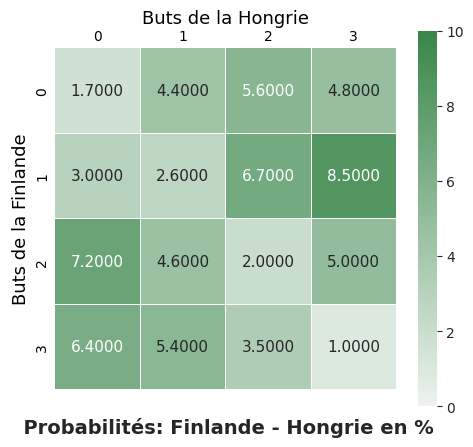

In [ ]:
def arrange_tableau(homeTeam,awayTeam):
  S=simulate_match_sp(homeTeam, awayTeam)
  tab=[ [] for i in range(len(S))]
  for i in range(len(S)):
    for j in range(len(S)):
      tab[i].append(round((S[i][j])*100,1))
  return tab

arrange_tableau("France", "Austria")
cmap = sns.diverging_palette(10, 133, as_cmap=True)
fig, ax = plt.subplots(figsize=(5,5))
with sns.axes_style("white"):
    ax = sns.heatmap(arrange_tableau("Finland","Hungary"),
                     annot=True, fmt='.4f', cmap=cmap, vmin=0, vmax=10, center=0.00,
                     square=True, linewidths=.5, annot_kws={"size": 11}, cbar_kws={"shrink": .8})
    ax.tick_params(axis=u'both', which=u'both',length=0)
    ax.grid(which='major', axis='both', linestyle='')
    ax.set_xlabel('Buts de la Hongrie', fontsize=13)
    ax.set_ylabel('Buts de la Finlande', fontsize=13)
    ax.xaxis.set_label_position('top')
    ax.xaxis.set_ticks_position('top')
    plt.figtext(0.45, 0.07, '  Probabilités: Finlande - Hongrie en %', horizontalalignment='center',
                fontsize=14, multialignment='left', fontweight='bold')
plt.tight_layout()
plt.show()


# Simulation de matchs par régression de poisson

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

goal_model_data = pd.concat([epl_1718[['HomeTeam','AwayTeam','HomeGoals']].assign(home=1).rename(
            columns={'HomeTeam':'team', 'AwayTeam':'opponent','HomeGoals':'goals'}),
           epl_1718[['AwayTeam','HomeTeam','AwayGoals']].assign(home=0).rename(
            columns={'AwayTeam':'team', 'HomeTeam':'opponent','AwayGoals':'goals'})])

goal_model_data


poisson_model_rg = smf.glm(formula="goals ~ team", data=goal_model_data,
                        family=sm.families.Poisson()).fit()
poisson_model_rg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  goals   No. Observations:                  478
Model:                            GLM   Df Residuals:                      425
Model Family:                 Poisson   Df Model:                           52
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -685.10
Date:                Sat, 06 Jul 2024   Deviance:                       545.43
Time:                        16:54:13   Pearson chi2:                     507.
No. Iterations:                    22   Pseudo R-squ. (CS):             0.3833
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       0.4055      0.289      1.405      0.160      -0.160       0.971
team[T.Andorra]                -1.6094      0.645     -2.493      0.013      -2.875      -0.344
team[T.Armenia]                -0.2877      0.441     -0.652      0.514      -1.152       0.577
team[T.Austria]                 0.3483      0.377      0.924      0.356      -0.391       1.087
team[T.Azerbaijan]             -0.5390      0.476     -1.133      0.257      -1.471       0.393
team[T.Belarus]                -0.5108      0.441     -1.158      0.247      -1.375       0.353
team[T.Belgium]                 0.6061      0.359      1.689      0.091      -0.097       1.310
team[T.Bosnia-Herzegovina]     -0.5008      0.428     -1.170      0.242      -1.340       0.338
team[T.Bulgaria]               -0.5390      0.476     -1.133      0.257      -1.471       0.393
team[T.Croatia]                 0.0800      0.400      0.200      0.842      -0.705       0.865
team[T.Cyprus]                 -1.3863      0.645     -2.148      0.032      -2.651      -0.121
team[T.Czech Republic]       2.528e-15      0.408   6.19e-15      1.000      -0.800       0.800
team[T.Denmark]                 0.2364      0.369      0.641      0.521      -0.486       0.959
team[T.England]                 0.6061      0.359      1.689      0.091      -0.097       1.310
team[T.Estonia]                -1.5041      0.645     -2.330      0.020      -2.769      -0.239
team[T.FYR Macedonia]          -0.1823      0.428     -0.426      0.670      -1.022       0.657
team[T.Faroe Islands]          -1.7918      0.764     -2.346      0.019      -3.289      -0.295
team[T.Finland]                 0.1411      0.369      0.383      0.702      -0.582       0.864
team[T.France]                  0.8824      0.343      2.571      0.010       0.210       1.555
team[T.Georgia]                -0.0690      0.393     -0.175      0.861      -0.840       0.702
team[T.Gibraltar]             -22.7315   1.51e+04     -0.002      0.999   -2.96e+04    2.96e+04
team[T.Greece]                  0.2364      0.369      0.641      0.521      -0.486       0.959
team[T.Hungary]                 0.2877      0.382      0.753      0.451      -0.461       1.036
team[T.Iceland]                 0.2007      0.359      0.559      0.576      -0.503       0.904
team[T.Israel]                 -0.3185      0.408     -0.780      0.435      -1.119       0.482
team[T.Italy]                   0.2877      0.382      0.753      0.451      -0.461       1.036
team[T.Kazakhstan]             -0.0308      0.382     -0.081      0.936      -0.779       0.718
team[T.Kosovo]                 -0.4055      0.428     -0.947      0.344      -1.245       0.434
team[T.Latvia]                 -0.8755      0.532     -1.645      0.100      -1.919       0.168
team[T.Liec

In [ ]:
def simulate_match_rg(foot_model, homeTeam, awayTeam, max_goals=10):
    home_goals_avg = foot_model.predict(pd.DataFrame(data={'team': homeTeam,
                                                            'homePoints': points(homeTeam), 'opponent':awayTeam, 'awayPoints': points(awayTeam)},
                                                      index=[1])).values[0]
    away_goals_avg = foot_model.predict(pd.DataFrame(data={'team': awayTeam,
                                                            'homePoints': points(awayTeam),'opponent':homeTeam, 'awayPoints': points(homeTeam)},
                                                      index=[1])).values[0]
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in [home_goals_avg, away_goals_avg]]
    return(np.outer(np.array(team_pred[0]), np.array(team_pred[1])))
simulate_match_rg(poisson_model_rg, 'Turkey', 'Greece', max_goals=5)

def arrange_tableau_rg(homeTeam,awayTeam):
  S=simulate_match_rg(poisson_model_rg, homeTeam, awayTeam, max_goals=3)
  tab=[ [] for i in range(len(S))]
  for i in range(len(S)):
    for j in range(len(S)):
      tab[i].append(round((S[i][j])*100,1))
  return tab

arrange_tableau_rg("England", "Switzerland")

[[0.7, 1.6, 1.7, 1.3],
 [1.9, 4.3, 4.7, 3.5],
 [2.7, 5.9, 6.5, 4.8],
 [2.5, 5.4, 5.9, 4.4]]

Affiche la matrice de probabilité de chaque score

```
# Ce texte est au format code
```



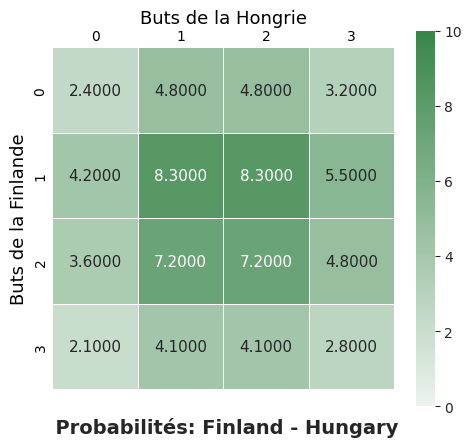

In [ ]:
cmap = sns.diverging_palette(10, 133, as_cmap=True)
fig, ax = plt.subplots(figsize=(5,5))
with sns.axes_style("white"):
    ax = sns.heatmap(arrange_tableau_rg("Finland","Hungary"),
                     annot=True, fmt='.4f', cmap=cmap, vmin=0, vmax=10, center=0.00,
                     square=True, linewidths=.5, annot_kws={"size": 11}, cbar_kws={"shrink": .8})
    ax.tick_params(axis=u'both', which=u'both',length=0)
    ax.grid(which='major', axis='both', linestyle='')
    ax.set_xlabel('Buts de la Hongrie', fontsize=13)
    ax.set_ylabel('Buts de la Finlande', fontsize=13)
    ax.xaxis.set_label_position('top')
    ax.xaxis.set_ticks_position('top')
    plt.figtext(0.45, 0.07, '  Probabilités: Finland - Hungary', horizontalalignment='center',
                fontsize=14, multialignment='left', fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
def prob_resultat(homeTeam, awayTeam):
  probMatrix=simulate_match_rg(poisson_model_rg, homeTeam, awayTeam, max_goals=10)
  homeTeamWin=np.sum(np.tril(probMatrix, -1))
  awayTeamWin=np.sum(np.triu(probMatrix, 1))
  Draw=np.sum(np.diag(probMatrix))
  return([homeTeamWin,Draw,awayTeamWin])

"""  print(homeTeam + " win: " + str(homeTeamWin))
  print(awayTeam + " win: " + str(awayTeamWin))
  print("Draw: " + str(Draw))"""
prob_resultat("Finland", "Hungary")

[0.3391112372829785, 0.2133526307020171, 0.44752570414628845]

In [ ]:
def difference_of_matrices(list1, list2):

  if len(list1) != len(list2):
    raise ValueError("Lists must have the same dimensions.")
  if len(list1[0]) != len(list2[0]):
    raise ValueError("Lists must have the same dimensions.")

  difference = []

  for i in range(len(list1)):
    row = []
    for j in range(len(list1[i])):
      difference_element = list1[i][j] - list2[i][j]
      row.append(difference_element)
    difference.append(row)
  return difference

list1 = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
list2 = [[10, 11, 12], [13, 14, 15], [16, 17, 18]]

difference = difference_of_matrices(arrange_tableau_rg("Finland","Hungary"), arrange_tableau("Finland","Hungary"))

print(difference)


[[0.7, 0.39999999999999947, -0.7999999999999998, -1.5999999999999996], [1.2000000000000002, 5.700000000000001, 1.6000000000000005, -3.0], [-3.6, 2.6000000000000005, 5.2, -0.20000000000000018], [-4.300000000000001, -1.3000000000000007, 0.5999999999999996, 1.7999999999999998]]


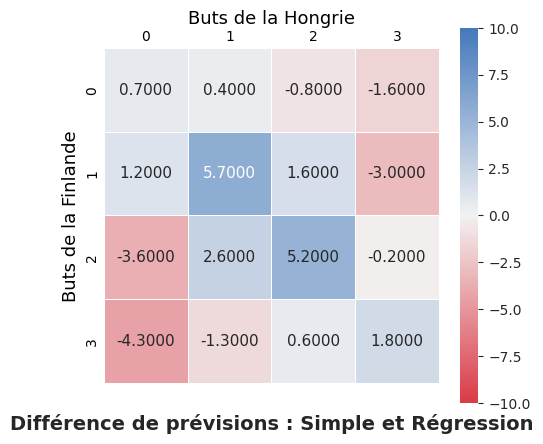

In [ ]:
###Différences entre modèles reg et simple :
cmap = sns.diverging_palette(10, 250, as_cmap=True)

fig, ax = plt.subplots(figsize=(5,5))
with sns.axes_style("white"):
    ax = sns.heatmap(difference,
                     annot=True, fmt='.4f', cmap=cmap, vmin=-10, vmax=10, center=0.00,
                     square=True, linewidths=.5, annot_kws={"size": 11}, cbar_kws={"shrink": .8})
    ax.tick_params(axis=u'both', which=u'both',length=0)
    ax.grid(which='major', axis='both', linestyle='')
    ax.set_xlabel('Buts de la Hongrie', fontsize=13)
    ax.set_ylabel('Buts de la Finlande', fontsize=13)
    ax.xaxis.set_label_position('top')
    ax.xaxis.set_ticks_position('top')
    plt.figtext(0.45, 0.07, 'Différence de prévisions : Simple et Régression', horizontalalignment='center',
                fontsize=14, multialignment='left', fontweight='bold')
plt.tight_layout()
plt.show()

# Regression de poisson en ajoutant le Fifa Ranking

In [ ]:
# importing the tools required for the Poisson regression model
import statsmodels.api as sm
import statsmodels.formula.api as smf

goal_model_data = tableau[['HomeTeam','AwayTeam','HomeGoals','Home_Team_Fifa_Points','Away_Team_Fifa_Points']].rename(
            columns={'HomeTeam':'team', 'AwayTeam':'opponent','HomeGoals':'goals','Home_Team_Fifa_Points':'homePoints','Away_Team_Fifa_Points':'awayPoints'})
goal_model_data


poisson_model_fk = smf.glm(formula="goals ~ homePoints + awayPoints", data=goal_model_data,
                        family=sm.families.Poisson()).fit()
poisson_model_fk.summary()
goal_model_data

,team,opponent,goals,homePoints,awayPoints
0,Kazakhstan,Slovenia,1,1198.24,1391.04
1,Italy,England,1,1726.58,1797.39
2,FYR Macedonia,Malta,2,1350.53,972.86
3,Denmark,Finland,3,1597.37,1419.47
4,San Marino,Northern Ireland,0,753.11,1361.17
...,...,...,...,...,...
234,Israel,Iceland,1,1323.81,1352.98
235,Bosnia-Herzegovina,Ukraine,1,1381.10,1541.25
236,Georgia,Greece,0,1312.80,1441.06
237,Wales,Poland,0,1506.04,1536.99


In [ ]:
def simulate_match_frk(foot_model, homeTeam, awayTeam, max_goals=3):
    home_goals_avg = foot_model.predict(pd.DataFrame(data={'team': homeTeam,
                                                            'homePoints': points(homeTeam), 'opponent':awayTeam, 'awayPoints': points(awayTeam)},
                                                      index=[1])).values[0]
    away_goals_avg = foot_model.predict(pd.DataFrame(data={'team': awayTeam,
                                                            'homePoints': points(awayTeam),'opponent':homeTeam, 'awayPoints': points(homeTeam)},
                                                      index=[1])).values[0]
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in [home_goals_avg, away_goals_avg]]
    return(np.outer(np.array(team_pred[0]), np.array(team_pred[1])))

simulate_match_frk(poisson_model_fk, 'England', 'Czech Republic', max_goals=3)

array([[0.02323715, 0.02308547, 0.01146739, 0.00379751],
       [0.06433276, 0.06391282, 0.03174781, 0.01051353],
       [0.0890536 , 0.0884723 , 0.0439474 , 0.01455351],
       [0.08218254, 0.08164609, 0.04055657, 0.01343061]])

In [ ]:
def prob_resultat_fk(homeTeam, awayTeam):
  probMatrix=simulate_match_frk(poisson_model_fk, homeTeam, awayTeam, max_goals=10)
  homeTeamWin=np.sum(np.tril(probMatrix, -1))
  awayTeamWin=np.sum(np.triu(probMatrix, 1))
  Draw=np.sum(np.diag(probMatrix))
  return([homeTeamWin,Draw,awayTeamWin])

prob_resultat_fk("Slovakia", "Romania")

[0.37797821955155575, 0.25094954498947214, 0.37107159443586857]

In [ ]:
def score_match(homeTeam, awayTeam):
  probMatrix=simulate_match_frk(poisson_model_fk, homeTeam, awayTeam, max_goals=3)
  max=0
  ind=[0,0]
  for i in range(4):
    for j in range(4):
      if probMatrix[i][j]>max:
        max=probMatrix[i][j]
        ind=[i,j]
  return max,ind

score_match("Turkey","England")

(0.09074505925454998, [0, 2])

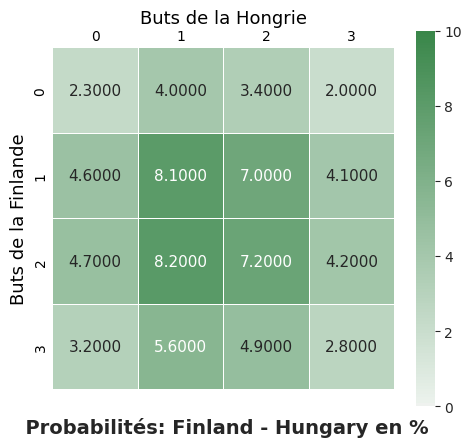

In [ ]:
def arrange_tableau_fk(homeTeam,awayTeam):
  S=simulate_match_frk(poisson_model_fk, homeTeam, awayTeam, max_goals=3)
  tab=[ [] for i in range(len(S))]
  for i in range(len(S)):
    for j in range(len(S)):
      tab[i].append(round((S[i][j])*100,1))
  return tab

arrange_tableau_rg("Finland", "Luxembourg")

cmap = sns.diverging_palette(10, 133, as_cmap=True)
fig, ax = plt.subplots(figsize=(5,5))
with sns.axes_style("white"):
    ax = sns.heatmap(arrange_tableau_fk("France","Belgium"),
                     annot=True, fmt='.4f', cmap=cmap, vmin=0, vmax=10, center=0.00,
                     square=True, linewidths=.5, annot_kws={"size": 11}, cbar_kws={"shrink": .8})
    ax.tick_params(axis=u'both', which=u'both',length=0)
    ax.grid(which='major', axis='both', linestyle='')
    ax.set_xlabel('Buts de la Hongrie', fontsize=13)
    ax.set_ylabel('Buts de la Finlande', fontsize=13)
    ax.xaxis.set_label_position('top')
    ax.xaxis.set_ticks_position('top')
    plt.figtext(0.45, 0.07, '  Probabilités: Finland - Hungary en %', horizontalalignment='center',
                fontsize=14, multialignment='left', fontweight='bold')
plt.tight_layout()
plt.show()

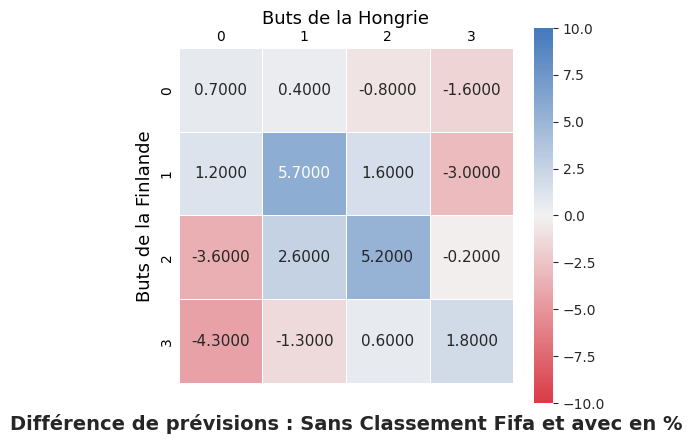

In [ ]:
###Différences entre modèles reg et simple :
cmap = sns.diverging_palette(10, 250, as_cmap=True)

fig, ax = plt.subplots(figsize=(5,5))
with sns.axes_style("white"):
    ax = sns.heatmap(difference,
                     annot=True, fmt='.4f', cmap=cmap, vmin=-10, vmax=10, center=0.00,
                     square=True, linewidths=.5, annot_kws={"size": 11}, cbar_kws={"shrink": .8})
    ax.tick_params(axis=u'both', which=u'both',length=0)
    ax.grid(which='major', axis='both', linestyle='')
    ax.set_xlabel('Buts de la Hongrie', fontsize=13)
    ax.set_ylabel('Buts de la Finlande', fontsize=13)
    ax.xaxis.set_label_position('top')
    ax.xaxis.set_ticks_position('top')
    plt.figtext(0.45, 0.07, 'Différence de prévisions : Sans Classement Fifa et avec en %', horizontalalignment='center',
                fontsize=14, multialignment='left', fontweight='bold')
plt.tight_layout()
plt.show()

difference = difference_of_matrices(arrange_tableau_fk("Finland","Hungary"), arrange_tableau_rg("Finland","Hungary"))

# Comparaison des modèles aux Bet Market


In [ ]:
def diff_list(l1,l2):
  L=[]
  for i in range(len(l1)):
    L.append(abs(l1[i]-l2[i]))
  return L

In [ ]:
def somme_listes(l1,l2):
  L=[]
  for i in range(len(l1)):
    L.append(l1[i]+l2[i])
  return L

def divise_liste(l1,x):
  L=[]
  for i in range(len(l1)):
    L.append(l1[i]/x)
  return L

In [ ]:
betodds = pd.read_csv('/content/drive/My Drive/CSV/bet.csv')
betodds2 = betodds[['Team1','Team2','prob1','probX','prob2']]
betodds2

,Team1,Team2,prob1,probX,prob2
0,Hungary,Switzerland,0.304878,0.290698,0.446429
1,Spain,Croatia,0.578035,0.264550,0.201207
2,Italy,Albania,0.729927,0.211416,0.107875
3,Poland,Netherlands,0.196464,0.247525,0.598802
4,Slovenia,Denmark,0.211416,0.273973,0.558659
5,Serbia,England,0.145138,0.220264,0.680272
6,Romania,Ukraine,0.283286,0.297619,0.460829
7,Belgium,Slovakia,0.671141,0.222717,0.151057
8,Austria,France,0.145773,0.213220,0.684932
9,Turkey,Georgia,0.564972,0.270270,0.210526


In [ ]:
def get_difference_reg():
  erreur_stat=[0,0,0]
  for i in range(0,22):
    homeTeam=betodds2['Team1'][i]
    awayTeam=betodds2['Team2'][i]
    index=i
    betPredictions=[betodds2['prob1'][i],betodds2['probX'][i],betodds2['prob2'][i]]
    regPredictions=prob_resultat(homeTeam, awayTeam)
    erreur_stat=somme_listes(erreur_stat, diff_list(betPredictions,regPredictions))
  return divise_liste(erreur_stat, 22)

def get_difference_reg_fk():
  erreur_stat=[0,0,0]
  for i in range(0,22):
    homeTeam=betodds2['Team1'][i]
    awayTeam=betodds2['Team2'][i]
    index=i
    betPredictions=[betodds2['prob1'][i],betodds2['probX'][i],betodds2['prob2'][i]]
    regPredictions=prob_resultat_fk(homeTeam, awayTeam)
    erreur_stat=somme_listes(erreur_stat, diff_list(betPredictions,regPredictions))
  return divise_liste(erreur_stat, 22)

def get_difference_sim():
  erreur_stat=[0,0,0]
  for i in range(0,22):
    homeTeam=betodds2['Team1'][i]
    awayTeam=betodds2['Team2'][i]
    index=i
    betPredictions=[betodds2['prob1'][i],betodds2['probX'][i],betodds2['prob2'][i]]
    simPredictions=probabilités_simple(homeTeam, awayTeam)
    erreur_stat=somme_listes(erreur_stat, diff_list(betPredictions,simPredictions))
  return divise_liste(erreur_stat, 22)

(get_difference_sim(),get_difference_reg(),get_difference_reg_fk())



([0.139927727476667, 0.0942449652990121, 0.13335999689389907],
 [0.11140319646405751, 0.07110864012864794, 0.09508869770037474],
 [0.05616073847402321, 0.07164051189382267, 0.05717392413647801])

# EURO 2024

In [ ]:
#ajustement côte Allemagne
for i in range(0,54):
  ind=0
  if fifarank['country_full'][i]=="Germany":
    fifarank['total_points'][i]=1636.32

all_scot=[0.76,0.15,0.09]
all_hungary=[0.73,0.17,0.10]
all_switz=[0.54,0.24,0.23]

for i in range(0,54):
  ind=0
  if fifarank['country_full'][i]=="Germany":
    fifarank['total_points'][i]=1797

L=prob_resultat_fk("Germany", "Scotland")

S=somme_listes(somme_listes(diff_list(all_scot,L),diff_list(all_hungary,L)),diff_list(all_switz,L))
print(S)

[0.22037964919214514, 0.1072917907700858, 0.15754438901870188]


<ipython-input-27-88a53bbfe32a>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fifarank['total_points'][i]=1636.32
<ipython-input-27-88a53bbfe32a>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fifarank['total_points'][i]=1797


In [ ]:
groupeA=['Germany','Scotland','Hungary','Switzerland']
groupeB=['Spain','Croatia','Italy','Albania']
groupeC=['Slovenia','Denmark','Serbia','England']
groupeD=['Poland','Netherlands','Austria','France']
groupeE=['Belgium','Slovakia','Romania','Ukraine']
groupeF=['Turkey','Georgia','Portugal','Czech Republic']

def classement_groupe(groupe):
  D={}
  for i in range(4):
    D[groupe[i]]=0
  for i in range(4):
    for j in range(0,4):
      homeTeam=groupe[i]
      if (i != j):
        awayTeam=groupe[j]
        prob=prob_resultat_fk(homeTeam, awayTeam)
        if prob[0]>=prob[2]:
          D[homeTeam]+=1
        else:
          D[awayTeam]+=1
  sorted_dict=sorted(D.items(), key=lambda x:x[1])
  return sorted_dict

print(classement_groupe(groupeA))
print(classement_groupe(groupeB))
print(classement_groupe(groupeC))
print(classement_groupe(groupeD))
print(classement_groupe(groupeE))
print(classement_groupe(groupeF))

[('Scotland', 0), ('Hungary', 2), ('Switzerland', 4), ('Germany', 6)]
[('Albania', 0), ('Croatia', 2), ('Italy', 4), ('Spain', 6)]
[('Slovenia', 0), ('Serbia', 2), ('Denmark', 4), ('England', 6)]
[('Poland', 0), ('Austria', 2), ('Netherlands', 4), ('France', 6)]
[('Romania', 0), ('Slovakia', 2), ('Ukraine', 4), ('Belgium', 6)]
[('Georgia', 0), ('Turkey', 2), ('Czech Republic', 4), ('Portugal', 6)]


In [ ]:
###Hutièmes de finale
homeTeam=classement_groupe(groupeB)[3][0]
awayTeam=classement_groupe(groupeD)[1][0]
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH1=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

homeTeam=classement_groupe(groupeA)[3][0]
awayTeam=classement_groupe(groupeC)[2][0]
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH2=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

homeTeam=classement_groupe(groupeF)[3][0]
awayTeam=classement_groupe(groupeC)[1][0]
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH3=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

homeTeam=classement_groupe(groupeD)[2][0]
awayTeam=classement_groupe(groupeE)[2][0]
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH4=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

homeTeam=classement_groupe(groupeE)[3][0]
awayTeam=classement_groupe(groupeB)[1][0]
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH5=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

homeTeam=classement_groupe(groupeD)[3][0]
awayTeam=classement_groupe(groupeF)[2][0]
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH6=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

homeTeam=classement_groupe(groupeC)[3][0]
awayTeam=classement_groupe(groupeF)[1][0]
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH7=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

homeTeam=classement_groupe(groupeA)[2][0]
awayTeam=classement_groupe(groupeB)[2][0]
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH8=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

Spain Austria Spain (0.09634310548949307, [2, 1]) [0.6038921621394491, 0.19759150170594117, 0.19849357679584573]
Germany Denmark Germany (0.09358714894320089, [2, 1]) [0.6389334939925133, 0.18318886186399796, 0.17782991342972765]
Portugal Serbia Portugal (0.09544195897560943, [2, 1]) [0.6490298756612186, 0.18353252879914875, 0.1673966692045903]
Netherlands Ukraine Netherlands (0.09583597313723483, [2, 1]) [0.6070536705630969, 0.1956661031836849, 0.19725467428949656]
Belgium Croatia Belgium (0.08791846715056986, [2, 1]) [0.48789347712851916, 0.2125155840013052, 0.29957940097085256]
France Czech Republic France (0.08805292154542488, [3, 0]) [0.7937180388375026, 0.12363006767343575, 0.08231573069740816]
England Turkey England (0.09074505925454998, [2, 0]) [0.762654954163057, 0.13933670704888818, 0.09782223318362578]
Switzerland Italy Italy (0.09357664946029692, [1, 2]) [0.26159809618786606, 0.21405811435447014, 0.5243336423711076]


In [ ]:
###Quarts de finale
homeTeam=winnerH1
awayTeam=winnerH2
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerQ1=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

homeTeam=winnerH3
awayTeam=winnerH4
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerQ2=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

homeTeam=winnerH5
awayTeam=winnerH6
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerQ3=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

homeTeam=winnerH7
awayTeam=winnerH8
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerQ4=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

Spain Germany Germany (0.08739137161430867, [1, 2]) [0.30466306005583654, 0.21288963861736904, 0.48243610679937393]
Portugal Netherlands Portugal (0.08965849956678042, [1, 1]) [0.3975097598225419, 0.2202919815450027, 0.3821924410700573]
Belgium France France (0.08248190254497224, [1, 2]) [0.3354227466404339, 0.21114358844167613, 0.4534212311489594]
England Italy England (0.08758429523733961, [2, 1]) [0.4835645755951933, 0.21295989646820213, 0.30346438397418934]


In [ ]:
###Demi Finale
homeTeam=winnerQ1
awayTeam=winnerQ2
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else:
  winner=awayTeam

print(prob[0],prob[1],prob[2])


winnerD1=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

homeTeam=winnerQ3
awayTeam=winnerQ4
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerD2=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

0.45516243001287204 0.214892646544146 0.32993554801360675
Germany Portugal Germany (0.08554295709201729, [1, 1]) [0.45516243001287204, 0.214892646544146, 0.32993554801360675]
France England France (0.08252238902361289, [2, 1]) [0.45384453838730754, 0.21112250285221149, 0.3350204991517619]


In [ ]:
###Finale!

homeTeam=winnerD1
awayTeam=winnerD2
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerFinal=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam), prob)

Germany France France (0.08226803227545607, [1, 2]) [0.3375383960863177, 0.21125030816364124, 0.4511989934449048]


# Euro 2020


In [ ]:
import pandas as pd
données=pd.read_csv('/content/drive/MyDrive/CSV/euro2020.csv')
données=données[['home_team_name','away_team_name','home_team_goal_count','away_team_goal_count']]
données.head()

epl_1718 = données.rename(columns={'home_team_goal_count': 'HomeGoals', 'away_team_goal_count': 'AwayGoals','home_team_name': 'HomeTeam','away_team_name': 'AwayTeam'})
epl_1718

goal_model_data = pd.concat([epl_1718[['HomeTeam','AwayTeam','HomeGoals']].assign(home=1).rename(
            columns={'HomeTeam':'team', 'AwayTeam':'opponent','HomeGoals':'goals'}),
           epl_1718[['AwayTeam','HomeTeam','AwayGoals']].assign(home=0).rename(
            columns={'AwayTeam':'team', 'HomeTeam':'opponent','AwayGoals':'goals'})])

poisson_model = smf.glm(formula="goals ~ team + opponent", data=goal_model_data,
                        family=sm.families.Poisson()).fit()
poisson_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  goals   No. Observations:                  102
Model:                            GLM   Df Residuals:                       55
Model Family:                 Poisson   Df Model:                           46
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -123.25
Date:                Sat, 06 Jul 2024   Deviance:                       62.700
Time:                        16:54:32   Pearson chi2:                     51.0
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4650
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -0.2183      0.698     -0.313      0.754      -1.586       1.149
team[T. Belgium ]                 1.0377      0.740      1.402      0.161      -0.413       2.488
team[T. Croatia ]                 1.5240      0.763      1.998      0.046       0.029       3.019
team[T. Czech Republic ]          0.4444      0.706      0.630      0.529      -0.938       1.827
team[T. Denmark ]                 1.6156      0.741      2.182      0.029       0.164       3.067
team[T. England ]                 0.5740      0.628      0.914      0.361      -0.657       1.805
team[T. Finland ]                -0.6216      1.214     -0.512      0.609      -3.001       1.758
team[T. France ]                  0.5498      0.774      0.711      0.477      -0.967       2.066
team[T. Germany ]                 0.8009      0.832      0.962      0.336      -0.830       2.432
team[T. Hungary ]                 0.1310      0.913      0.143      0.886      -1.659       1.921
team[T. Italy ]                   0.9878      0.681      1.450      0.147      -0.347       2.323
team[T. Netherlands ]             0.5052      0.587      0.861      0.389      -0.644       1.655
team[T. North Macedonia ]        -0.5329      0.863     -0.618      0.537      -2.224       1.158
team[T. Poland ]                  0.2559      0.841      0.304      0.761      -1.392       1.904
team[T. Portugal ]                0.8667      0.808      1.073      0.283      -0.716       2.450
team[T. Russia ]                  0.3939      0.990      0.398      0.691      -1.546       2.334
team[T. Scotland ]               -0.6036      1.193     -0.506      0.613      -2.942       1.735
team[T. Slovakia ]               -0.4556      0.980     -0.465      0.642      -2.376       1.465
team[T. Spain ]                   0.5537      0.680      0.814      0.415      -0.779       1.886
team[T. Sweden ]                 -0.1571      0.743     -0.211      0.833      -1.614       1.300
team[T. Switzerland ]             0.8023      0.741      1.083      0.279      -0.650       2.254
team[T. Turkey ]                 -0.7696      1.192     -0.645      0.519      -3.107       1.567
team[T. Ukraine ]                 0.2547      0.634      0.402      0.688      -0.988       1.498
team[T. Wales ]                  -0.2266      0.860     -0.264      0.792      -1.912       1.459
opponent[T. Belgium ]            -1.1776      0.822     -1.433      0.152      -2.788       0.433
opponent[T. Croatia ]             0.5711      0.684      0.835      0.404      -0.769       1.911
opponent[T. Czech Republic ]     -1.0056      0.757     -1.329      0.184      -2.489       0.477
opponent[T. Denmark ]            -0.0303      0.709     -0.043      0.966      -1.420       1.359
opponent[T. England ]            -1.9751     

In [ ]:
def simulate_match(foot_model, homeTeam, awayTeam, max_goals=10):
    home_goals_avg = foot_model.predict(pd.DataFrame(data={'team': homeTeam,
                                                            'homePoints': points(homeTeam), 'opponent':awayTeam, 'awayPoints': points(awayTeam)},
                                                      index=[1])).values[0]
    away_goals_avg = foot_model.predict(pd.DataFrame(data={'team': awayTeam,
                                                            'homePoints': points(awayTeam),'opponent':homeTeam, 'awayPoints': points(homeTeam)},
                                                      index=[1])).values[0]
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in [home_goals_avg, away_goals_avg]]
    return(np.outer(np.array(team_pred[0]), np.array(team_pred[1])))

groupeA=[' Turkey ',' Italy ',' Wales ',' Switzerland ']
groupeB=[' Denmark ',' Finland ',' Belgium ',' Russia ']
groupeC=[' Netherlands ',' Ukraine ',' Austria ',' North Macedonia ']
groupeD=[' England ',' Croatia ',' Scotland ',' Czech Republic ']
groupeE=[' Spain ',' Sweden ',' Poland ',' Slovakia ']
groupeF=[' Hungary ',' Portugal ',' France ',' Germany ']

def prob_resultat(homeTeam, awayTeam):
  probMatrix=simulate_match_rg(poisson_model, homeTeam, awayTeam, max_goals=10)
  homeTeamWin=np.sum(np.tril(probMatrix, -1))
  awayTeamWin=np.sum(np.triu(probMatrix, 1))
  Draw=np.sum(np.diag(probMatrix))
  return([homeTeamWin,Draw,awayTeamWin])

def classement_groupe(groupe):
  D={}
  for i in range(4):
    D[groupe[i]]=0
  for i in range(4):
    for j in range(0,4):
      homeTeam=groupe[i]
      if (i != j):
        awayTeam=groupe[j]
        prob=prob_resultat(homeTeam, awayTeam)
        if prob[0]>=prob[2]:
          D[homeTeam]+=1
        else:
          D[awayTeam]+=1
  sorted_dict=sorted(D.items(), key=lambda x:x[1])
  return sorted_dict

def score_match(homeTeam, awayTeam):
  probMatrix=simulate_match_rg(poisson_model, homeTeam, awayTeam, max_goals=3)
  max=0
  ind=[0,0]
  for i in range(4):
    for j in range(4):
      if probMatrix[i][j]>max:
        max=probMatrix[i][j]
        ind=[i,j]
  return max,ind

print(classement_groupe(groupeA))
print(classement_groupe(groupeB))
print(classement_groupe(groupeC))
print(classement_groupe(groupeD))
print(classement_groupe(groupeE))
print(classement_groupe(groupeF))

###Hutièmes de finale
homeTeam=" Belgium "
awayTeam=" Portugal "
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH1=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

homeTeam=" Italy "
awayTeam=" Austria "
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH2=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

homeTeam=" France "
awayTeam=" Switzerland "
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH3=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

homeTeam=" Croatia "
awayTeam=" Spain "
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH4=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

homeTeam=" Sweden "
awayTeam=" Ukraine "
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH5=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

homeTeam=" England "
awayTeam=" Germany "
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH6=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

homeTeam=" Netherlands "
awayTeam=" Czech Republic "
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH7=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

homeTeam=" Wales "
awayTeam=" Denmark "
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerH8=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))
###Quarts de finale
homeTeam=winnerH1
awayTeam=winnerH2
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerQ1=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

homeTeam=winnerH3
awayTeam=winnerH4
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerQ2=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

homeTeam=winnerH5
awayTeam=winnerH6
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerQ3=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

homeTeam=winnerH7
awayTeam=winnerH8
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerQ4=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))
###Demi Finale
homeTeam=winnerQ1
awayTeam=winnerQ2
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else:
  winner=awayTeam

print(prob[0],prob[1],prob[2])


winnerD1=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

homeTeam=winnerQ3
awayTeam=winnerQ4
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerD2=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

###Finale!

homeTeam=winnerD1
awayTeam=winnerD2
prob=prob_resultat_fk(homeTeam, awayTeam)
if prob[0]>=prob[2]:
  winner=homeTeam
else: winner=awayTeam
winnerFinal=winner
print(homeTeam,awayTeam,winner, score_match(homeTeam,awayTeam))

prob_resultat(" Italy ", " Spain ")

[(' Turkey ', 0), (' Wales ', 2), (' Switzerland ', 4), (' Italy ', 6)]
[(' Finland ', 0), (' Russia ', 2), (' Denmark ', 4), (' Belgium ', 6)]
[(' North Macedonia ', 0), (' Ukraine ', 2), (' Austria ', 4), (' Netherlands ', 6)]
[(' Scotland ', 0), (' Croatia ', 2), (' Czech Republic ', 4), (' England ', 6)]
[(' Slovakia ', 0), (' Poland ', 2), (' Sweden ', 4), (' Spain ', 6)]
[(' Hungary ', 0), (' Germany ', 2), (' France ', 4), (' Portugal ', 6)]


AttributeError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
'DataFrame' object has no attribute 'dtype'

# DC Model, bonus

In [ ]:
def dc_log_like(x, y, alpha_x, beta_x, alpha_y, beta_y, rho, gamma):
    lambda_x, mu_y = np.exp(alpha_x + beta_y), np.exp(alpha_y + beta_x)
    return (np.log(poisson.pmf(x, lambda_x)) + np.log(poisson.pmf(y, mu_y)))

def solve_parameters(dataset, debug = False, init_vals=None, options={'disp': True, 'maxiter':100},
                     constraints = [{'type':'eq', 'fun': lambda x: sum(x[:20])-20}] , **kwargs):
    teams = np.sort(dataset['HomeTeam'].unique())

    if init_vals is None:
        # Initialisation aléatoire des paramètres
        init_vals = np.concatenate((np.random.uniform(0,1,(n_teams)), # Force d'attaque
                                      np.random.uniform(0,-1,(n_teams)), # Force de défense
                                     ))
    print(init_vals)
    def dc_log_like(x, y, alpha_x, beta_x, alpha_y, beta_y):
        lambda_x, mu_y = np.exp(alpha_x + beta_y), np.exp(alpha_y + beta_x)
        return (np.log(poisson.pmf(x, lambda_x)) + np.log(poisson.pmf(y, mu_y)))

    def estimate_paramters(params):
        score_coefs = dict(zip(teams, params[:n_teams]))
        defend_coefs = dict(zip(teams, params[n_teams:(2*n_teams)]))
        log_like = [dc_log_like(row.HomeGoals, row.AwayGoals, score_coefs[row.HomeTeam], defend_coefs[row.HomeTeam],
                     score_coefs[row.AwayTeam], defend_coefs[row.AwayTeam] for row in dataset.itertuples()]
        print(-sum(log_like))
        return -sum(log_like)

    opt_output = minimize(estimate_paramters, init_vals, options=options, constraints = constraints, **kwargs)


    return dict(zip(["attack_"+team for team in teams] +
                        ["defence_"+team for team in teams]],

                        opt_output.x))

solve_parameters(tableau)

In [ ]:
tableau

In [ ]:
params={'attack_Albania': 1.5588989499844084,
 'attack_Andorra': -0.7132454018825906,
 'attack_Armenia': 1.3271054230595076,
 'attack_Austria': 1.1930419246678428,
 'attack_Azerbaijan': 0.4722606319203112,
 'attack_Belarus': 0.3117175637344285,
 'attack_Belgium': 1.397255088778856,
 'attack_Bosnia-Herzegovina': 1.1324348317446344,
 'attack_Bulgaria': 0.4475932795356825,
 'attack_Croatia': 1.53442478024527,
 'attack_Cyprus': 0.9628272337769449,
 'attack_Czech Republic': 1.6228018919948033,
 'attack_Denmark': 0.4679698104094707,
 'attack_England': 2.1358255079384967,
 'attack_Estonia': -0.3690096603718759,
 'attack_FYR Macedonia': 1.6786784022123384,
 'attack_Faroe Islands': -0.03602861606939084,
 'attack_Finland': 0.45169926814317973,
 'attack_France': 2.433027919574684,
 'attack_Georgia': 1.9907211376789875,
 'attack_Gibraltar': -12.092967744446211,
 'attack_Greece': 1.6535386014413638,
 'attack_Hungary': 1.1553115657306459,
 'attack_Iceland': 1.7203243541657631,
 'attack_Israel': 0.5084120556228477,
 'attack_Italy': 1.913165051675244,
 'attack_Kazakhstan': 0.3029711690287984,
 'attack_Kosovo': 0.35299456278842534,
 'attack_Latvia': 0.9267159243528204,
 'attack_Liechtenstein': -1.0373803886318187,
 'attack_Lithuania': 0.5887533628653139,
 'attack_Luxembourg': 1.3736698208645362,
 'attack_Malta': -0.01603622838947939,
 'attack_Moldova': 1.1761897359161377,
 'attack_Montenegro': 0.6419964725930145,
 'attack_Netherlands': 1.9624011897492564,
 'attack_Northern Ireland': -0.2590082095684746,
 'attack_Norway': 2.2583444817192677,
 'attack_Poland': 1.491606221415408,
 'attack_Portugal': 2.263851547881049,
 'attack_Republic of Ireland': 1.360588773793498,
 'attack_Romania': 0.7531094788930679,
 'attack_San Marino': -1.1206504856202144,
 'attack_Scotland': 2.3847585400880846,
 'attack_Serbia': 1.1377767537862908,
 'attack_Slovakia': 1.580322824910416,
 'attack_Slovenia': 0.5060137534059493,
 'attack_Spain': 2.729747831520095,
 'attack_Sweden': 1.100007074869693,
 'attack_Switzerland': 1.2067963358287894,
 'attack_Turkey': 1.6896001995283878,
 'attack_Ukraine': 1.5354440920440964,
 'attack_Wales': 1.3154852410401012,
 'defence_Albania': -1.9256163984128283,
 'defence_Andorra': 0.008225176827775717,
 'defence_Armenia': -1.0869430709118237,
 'defence_Austria': -0.9818627536524341,
 'defence_Azerbaijan': -0.2611695736637415,
 'defence_Belarus': -0.256029230747799,
 'defence_Belgium': -1.4581771815265552,
 'defence_Bosnia-Herzegovina': -0.8863627452874429,
 'defence_Bulgaria': -0.35627600787127756,
 'defence_Croatia': -2.0438695805593463,
 'defence_Cyprus': -1.1238319106495085,
 'defence_Czech Republic': -1.4969117269973735,
 'defence_Denmark': -0.12770802430212447,
 'defence_England': -2.183658484385028,
 'defence_Estonia': -0.04852384536035711,
 'defence_FYR Macedonia': -0.7356126441093289,
 'defence_Faroe Islands': -0.9907416978917585,
 'defence_Finland': -0.07836643418673205,
 'defence_France': -2.38194797913556,
 'defence_Georgia': -1.5630422976528633,
 'defence_Gibraltar': -0.298670630137614,
 'defence_Greece': -1.9000952303015568,
 'defence_Hungary': -0.8739580838658548,
 'defence_Iceland': -0.969088335184289,
 'defence_Israel': -0.43079879292961476,
 'defence_Italy': -1.4637978372622966,
 'defence_Kazakhstan': -0.004342246308641339,
 'defence_Kosovo': -0.5860405468021649,
 'defence_Latvia': -0.6138908595746247,
 'defence_Liechtenstein': -0.6610182987421317,
 'defence_Lithuania': -0.33232009051638634,
 'defence_Luxembourg': -0.9511650166606258,
 'defence_Malta': -0.9258483164884106,
 'defence_Moldova': -1.1137746057769606,
 'defence_Montenegro': -0.5634416349548242,
 'defence_Netherlands': -1.7685537703008931,
 'defence_Northern Ireland': -0.0009850662579403322,
 'defence_Norway': -1.7952133799839733,
 'defence_Poland': -1.08250871015729,
 'defence_Portugal': -2.882104188905927,
 'defence_Republic of Ireland': -1.5574973366833897,
 'defence_Romania': -1.1980599920455193,
 'defence_San Marino': 0.8018080343069913,
 'defence_Scotland': -2.1643446612733404,
 'defence_Serbia': -0.6291885722298556,
 'defence_Slovakia': -1.7322863214703001,
 'defence_Slovenia': -0.22210408612527185,
 'defence_Spain': -2.4970965730755066,
 'defence_Sweden': -0.4738195504591358,
 'defence_Switzerland': -0.2505103745767994,
 'defence_Turkey': -1.432388348716135,
 'defence_Ukraine': -1.645748139136086,
 'defence_Wales': -1.258429432934213}

def calc_means_euro(param_dict, homeTeam, awayTeam):
    if (homeTeam=="Germany"):
      return [np.exp(param_dict['attack_'+homeTeam] + param_dict['defence_'+awayTeam] + 0.19642),
              np.exp(param_dict['defence_'+homeTeam] + param_dict['attack_'+awayTeam])]
    if (awayTeam=="Germany"):
      return [np.exp(param_dict['attack_'+homeTeam] + param_dict['defence_'+awayTeam]),
              np.exp(param_dict['defence_'+homeTeam] + param_dict['attack_'+awayTeam] + 0.19642)]
    else:
      return [np.exp(param_dict['attack_'+homeTeam] + param_dict['defence_'+awayTeam]),
              np.exp(param_dict['defence_'+homeTeam] + param_dict['attack_'+awayTeam])]

def dixon_coles_simulate_match(params_dict, homeTeam, awayTeam, max_goals=10):
    team_avgs = calc_means_euro(params_dict, homeTeam, awayTeam)
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in team_avgs]
    output_matrix = np.outer(np.array(team_pred[0]), np.array(team_pred[1]))
    output_matrix[:2,:2] = output_matrix[:2,:2]
    return output_matrix

dixon_coles_simulate_match(params, 'Turkey', 'Czech Republic', max_goals=10)

In [ ]:
ars_sou_dc = dixon_coles_simulate_match(params, 'Italy', 'Spain', max_goals=10)
# [Simple Poisson, Dixon-Coles]
print("France")
print('; '.join("{0}: {1:.5f}".format(model, prob) for model,prob in
          zip(["Dixon-Coles"], list(map(lambda x:np.sum(np.tril(x, -1)), [ars_sou_dc])))))
print("Spain")
print('; '.join("{0}: {1:.5f}".format(model, prob) for model,prob in
          zip(["Dixon-Coles"], list(map(lambda x:np.sum(np.triu(x, 1)), [ars_sou_dc])))))
print("Draw")
print('; '.join("{0}: {1:.5f}".format(model, prob) for model,prob in
          zip(["Dixon-Coles"], list(map(lambda x:np.sum(np.diag(x)), [ars_sou_dc])))))

ars_sou_dc